# Seaborn Mastery: The Complelete Data Visualization Training Notebook

## 1. Imports and Environment Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#set a professional, consistent visual theme for the whole notebook
sns.set_theme(style = "whitegrid", palette = "deep")
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully")
print("Seaborn version:", sns.__version__)

Libraries imported successfully
Seaborn version: 0.13.2


In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Apply default plotting style
sns.set_style("whitegrid")
sns.set_palette("deep")

# Set figure resolution
plt.rcParams["figure.dpi"] = 100

# Verify successful imports
print("All libraries loaded successfully!")
print(f"NumPy Version   : {np.__version__}")
print(f"Pandas Version  : {pd.__version__}")
print(f"Matplotlib Version : {plt.matplotlib.__version__}")
print(f"Seaborn Version : {sns.__version__}")

All libraries loaded successfully!
NumPy Version   : 2.4.6
Pandas Version  : 2.3.1
Matplotlib Version : 3.10.3
Seaborn Version : 0.13.2


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Configure plotting style
plt.style.use("ggplot")
sns.set_palette("deep")

# Improve image quality
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")
print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

Libraries imported successfully.
NumPy : 2.4.6
Pandas: 2.3.1
Matplotlib: 3.10.3
Seaborn: 0.13.2


## 2. Dataset Loading

In [3]:
# load the dataset 
df = sns.load_dataset("titanic")

# Alternativ if you have a local file:
# df = pd.read_csv("titanic.csv")

df

NameError: name 'sns' is not defined

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [14]:
df.shape

(891, 15)

In [16]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [18]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [19]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(107)

In [23]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [24]:
df['pclass'].unique()

array([3, 1, 2])

In [25]:
for col in df.columns:
    print(f"{col:14s} -> {df[col].unique()} unique values")

survived       -> [0 1] unique values
pclass         -> [3 1 2] unique values
sex            -> ['male' 'female'] unique values
age            -> [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ] unique values
sibsp          -> [1 0 3 4 2 5 8] unique values
parch          -> [0 1 2 5 3 4 6] unique values
fare           -> [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5  

## 4. EDA Concepts -- The Theory before The Charts

## 5. Histogram -- sns.histplot() / sns.displot()

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


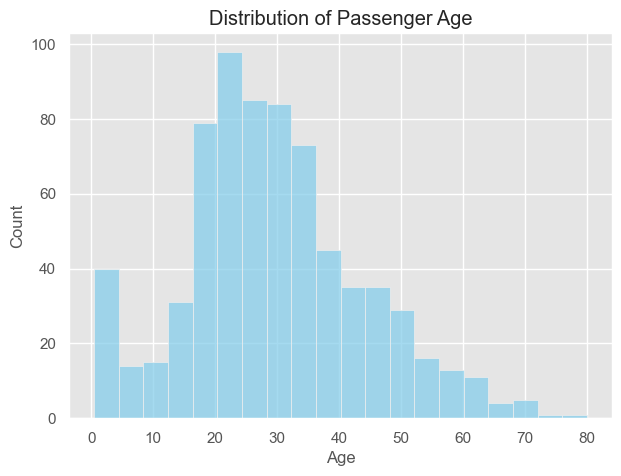

In [26]:
# Histogram of passenger age
plt.figure(figsize=(7,5))

sns.histplot(data=df, x="age", bins=20, color="skyblue")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

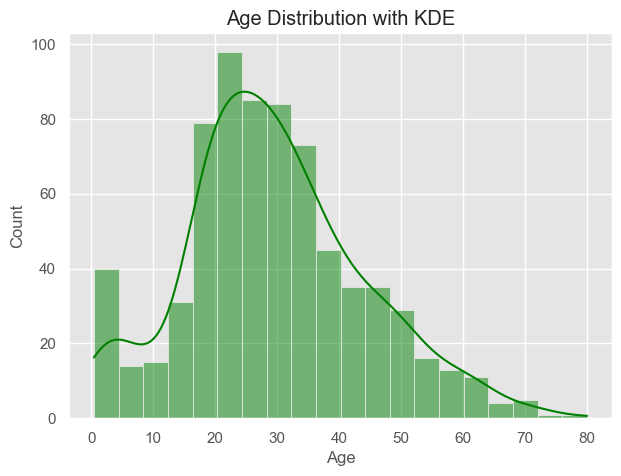

In [30]:
# Histogram with KDE curve
plt.figure(figsize=(7,5))

sns.histplot(data=df, x="age", kde=True, color="green")

plt.title("Age Distribution with KDE")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

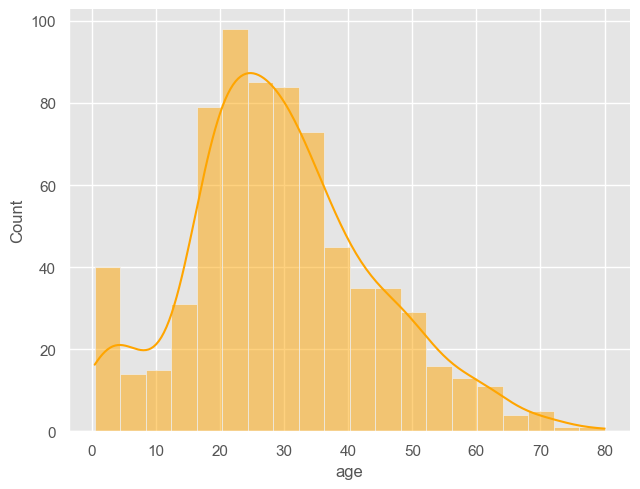

In [31]:
# Distribution plot of passenger age
sns.displot(
    data=df,
    x="age",
    bins=20,
    kde=True,
    color="orange",
    height=5,
    aspect=1.3
)

plt.show()

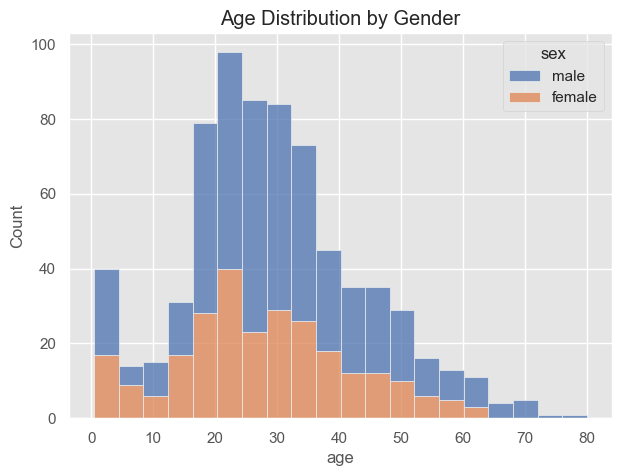

In [32]:
# Histogram by gender
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="age",
    hue="sex",
    bins=20,
    multiple="stack"
)

plt.title("Age Distribution by Gender")
plt.show()

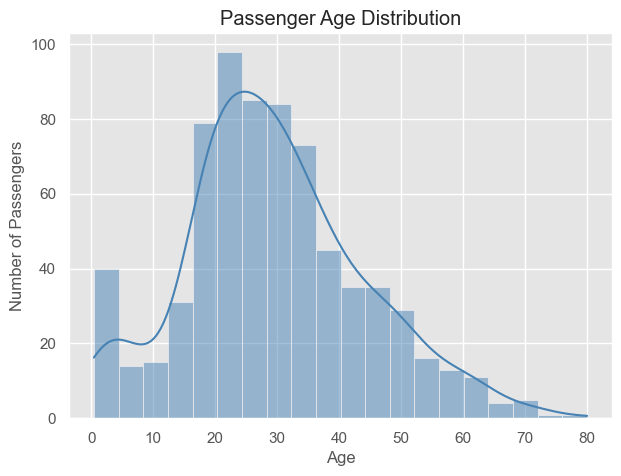

In [33]:
# Histogram – Passenger Age Distribution
# Real Industry Example:
# A cruise or airline company analyzes passenger age distribution
# to understand customer demographics and improve services.

import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
df = sns.load_dataset("titanic")

plt.figure(figsize=(7,5))

sns.histplot(data=df, x="age", bins=20, kde=True, color="steelblue")

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## 5. Box Plot - sns.boxploat()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\1474695179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


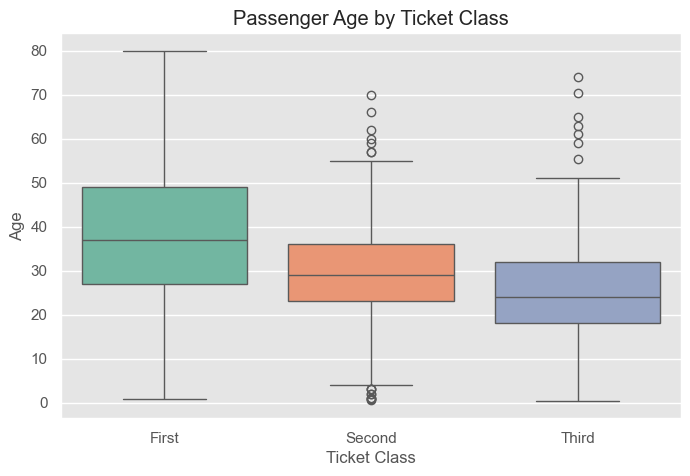

In [34]:
## 5. Box Plot - sns.boxplot()

# Real Industry Example:
# A travel company compares passenger age across different
# ticket classes to understand customer demographics.

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="class",
    y="age",
    palette="Set2"
)

plt.title("Passenger Age by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Age")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\1920920464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


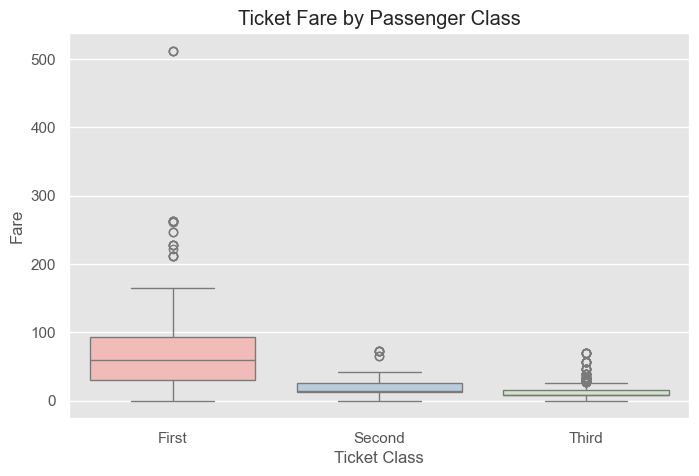

In [35]:
## Box Plot - Ticket Fare by Passenger Class

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="class",
    y="fare",
    palette="Pastel1"
)

plt.title("Ticket Fare by Passenger Class")
plt.xlabel("Ticket Class")
plt.ylabel("Fare")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\598995932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


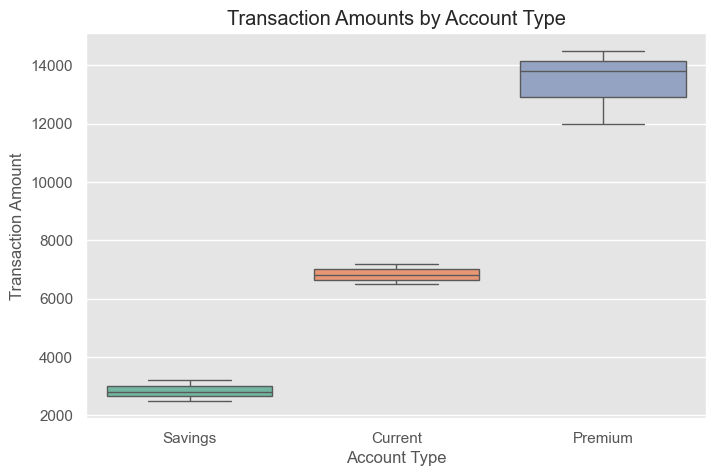

In [36]:
## 5. Box Plot - sns.boxplot()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Banking Dataset
bank_df = pd.DataFrame({
    "Account_Type": ["Savings","Savings","Savings","Current","Current","Current",
                     "Premium","Premium","Premium"],
    "Transaction_Amount": [2500, 3200, 2800, 6500, 7200, 6800, 12000, 14500, 13800]
})

plt.figure(figsize=(8,5))

sns.boxplot(
    data=bank_df,
    x="Account_Type",
    y="Transaction_Amount",
    palette="Set2"
)

plt.title("Transaction Amounts by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Transaction Amount")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\376089475.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


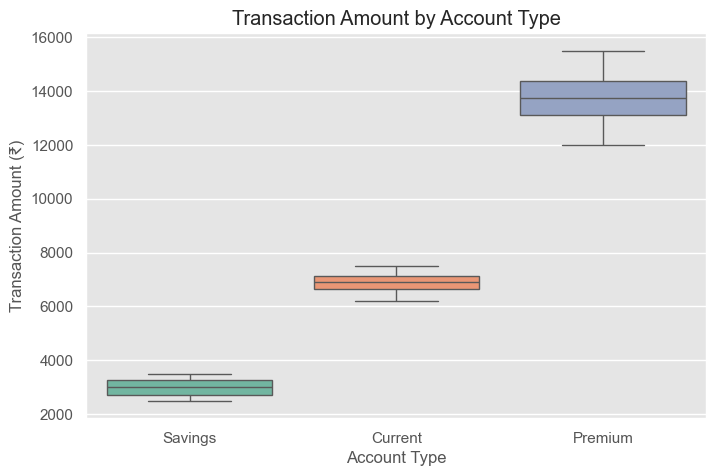

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Banking Dataset
bank_df = pd.DataFrame({
    "Account_Type": ["Savings","Savings","Savings","Savings",
                     "Current","Current","Current","Current",
                     "Premium","Premium","Premium","Premium"],
    "Transaction_Amount": [2500, 3200, 2800, 3500,
                           6200, 7000, 6800, 7500,
                           12000, 13500, 14000, 15500]
})

plt.figure(figsize=(8,5))

sns.boxplot(
    data=bank_df,
    x="Account_Type",
    y="Transaction_Amount",
    palette="Set2"
)

plt.title("Transaction Amount by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Transaction Amount (₹)")

plt.show()

## 8. Relplot - sns,relplot()

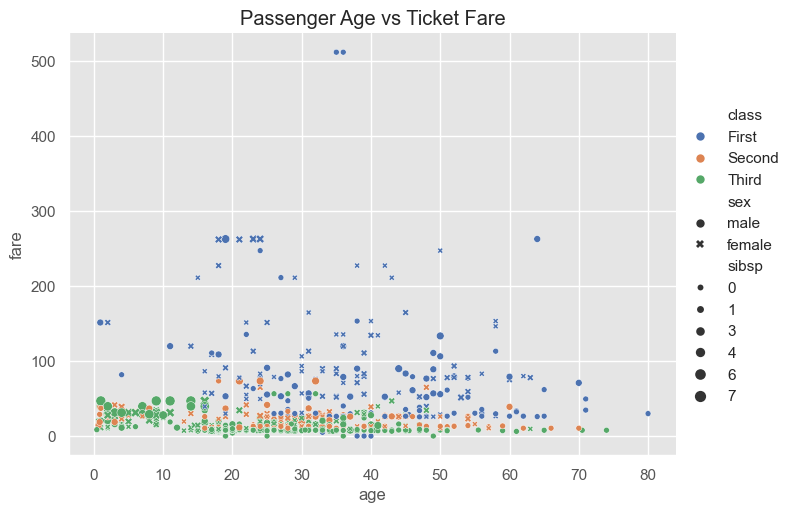

In [39]:
## 8. Relplot - sns.relplot()

# Real Industry Example:
# Travel companies analyze the relationship between passenger age
# and ticket fare across different travel classes.

sns.relplot(
    data=df,
    x="age",
    y="fare",
    hue="class",
    style="sex",
    size="sibsp",
    height=5,
    aspect=1.4
)

plt.title("Passenger Age vs Ticket Fare")
plt.show()

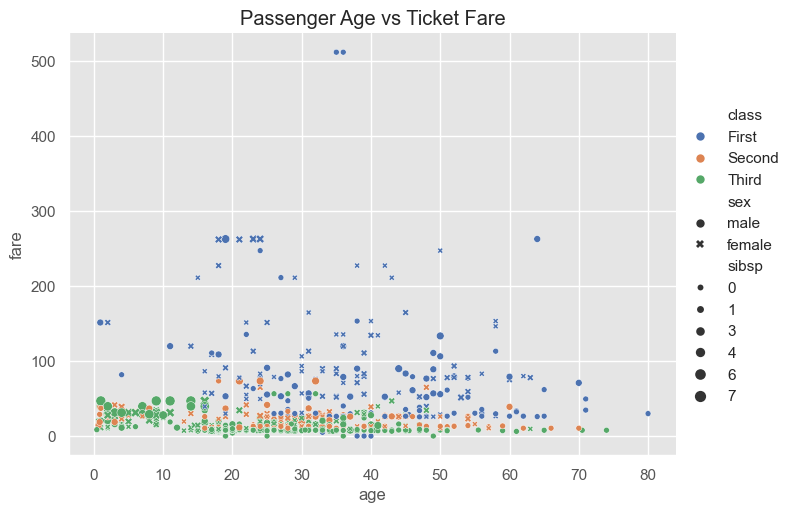

In [40]:
## 8. Relplot - sns.relplot()

# Real Industry Example:
# Travel companies analyze the relationship between passenger age
# and ticket fare across different travel classes.

sns.relplot(
    data=df,
    x="age",
    y="fare",
    hue="class",
    style="sex",
    size="sibsp",
    height=5,
    aspect=1.4
)

plt.title("Passenger Age vs Ticket Fare")
plt.show()

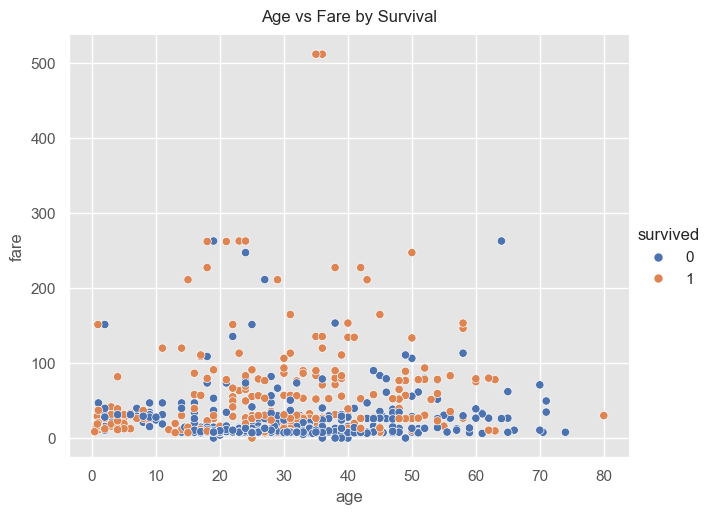

In [41]:
## Relplot - Passenger Age vs Fare

sns.relplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    kind="scatter",
    height=5,
    aspect=1.3
)

plt.suptitle("Age vs Fare by Survival", y=1.02)
plt.show()

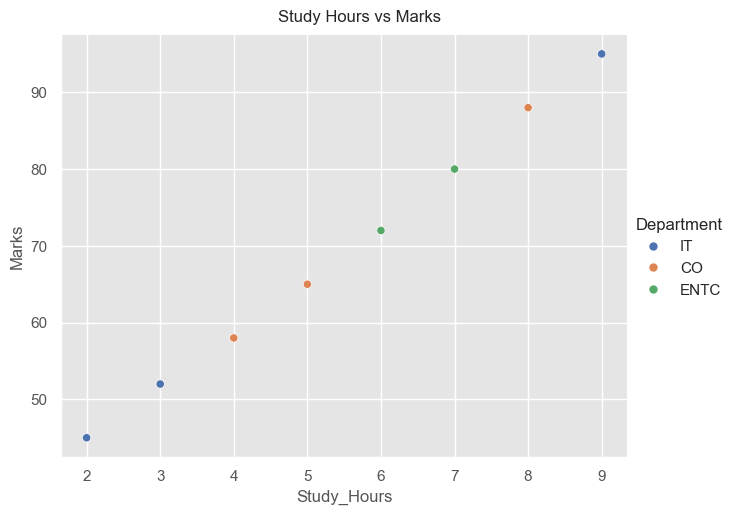

In [42]:
## Intermediate Example: Student Performance Analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Student Dataset
student_df = pd.DataFrame({
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "Marks": [45, 52, 58, 65, 72, 80, 88, 95],
    "Department": ["IT", "IT", "CO", "CO", "ENTC", "ENTC", "CO", "IT"]
})

sns.relplot(
    data=student_df,
    x="Study_Hours",
    y="Marks",
    hue="Department",
    kind="scatter",
    height=5,
    aspect=1.3
)

plt.suptitle("Study Hours vs Marks", y=1.02)
plt.show()

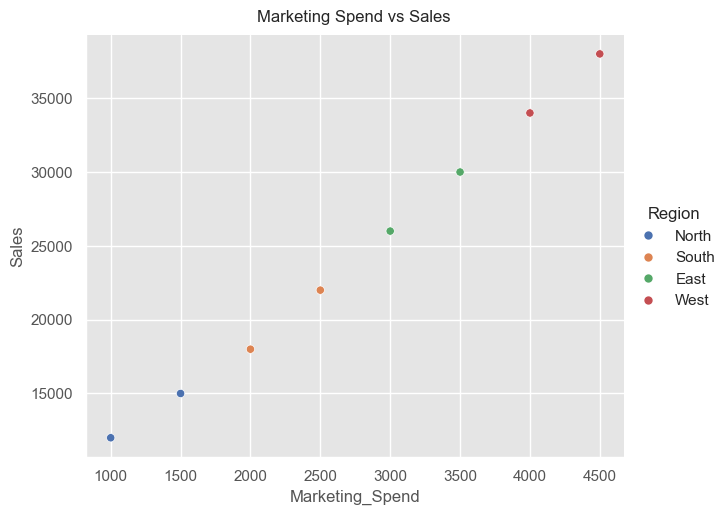

In [43]:
## Real Industry Example: E-Commerce Sales Analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample E-Commerce Dataset
sales_df = pd.DataFrame({
    "Marketing_Spend": [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500],
    "Sales": [12000, 15000, 18000, 22000, 26000, 30000, 34000, 38000],
    "Region": ["North", "North", "South", "South", "East", "East", "West", "West"]
})

sns.relplot(
    data=sales_df,
    x="Marketing_Spend",
    y="Sales",
    hue="Region",
    kind="scatter",
    height=5,
    aspect=1.3
)

plt.suptitle("Marketing Spend vs Sales", y=1.02)
plt.show()

## 9. Line Plot -- sns.lineplot()

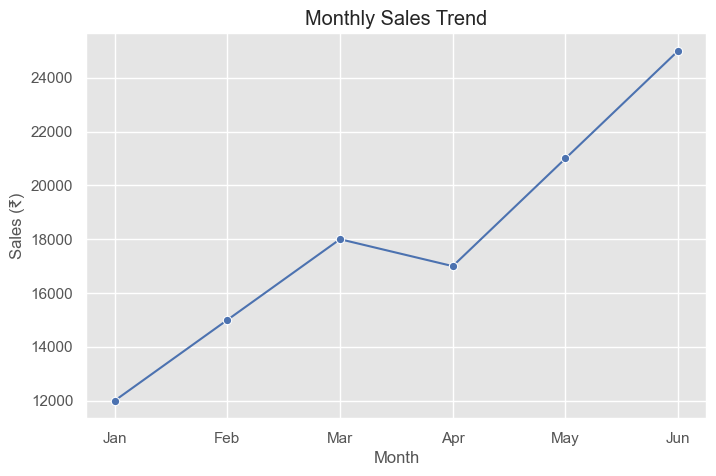

In [44]:
## 9. Line Plot - sns.lineplot()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Monthly Sales Dataset
sales_df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [12000, 15000, 18000, 17000, 21000, 25000]
})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=sales_df,
    x="Month",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.show()

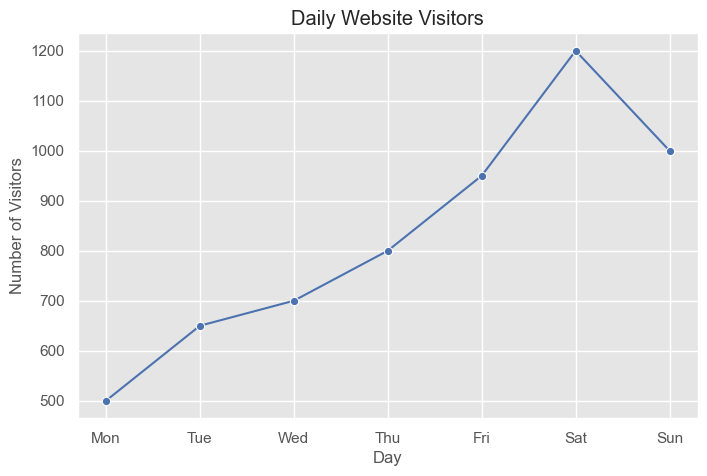

In [45]:
## Intermediate Example: Website Traffic Analysis

traffic_df = pd.DataFrame({
    "Day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    "Visitors": [500, 650, 700, 800, 950, 1200, 1000]
})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=traffic_df,
    x="Day",
    y="Visitors",
    marker="o"
)

plt.title("Daily Website Visitors")
plt.xlabel("Day")
plt.ylabel("Number of Visitors")
plt.show()

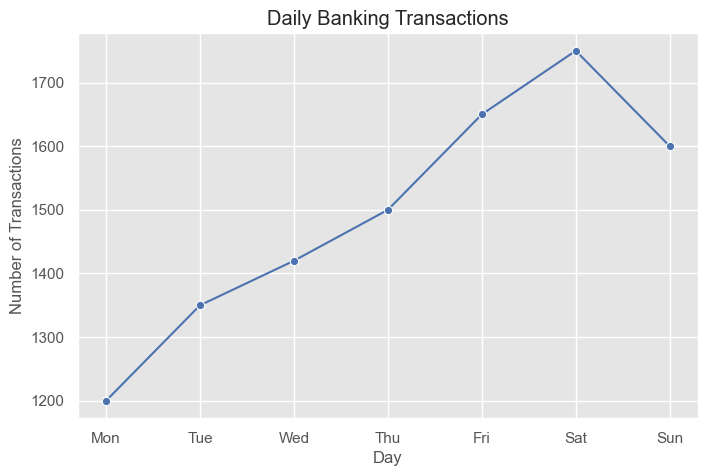

In [46]:
## Real Industry Example: Banking - Daily Transactions

bank_df = pd.DataFrame({
    "Day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    "Transactions": [1200, 1350, 1420, 1500, 1650, 1750, 1600]
})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=bank_df,
    x="Day",
    y="Transactions",
    marker="o"
)

plt.title("Daily Banking Transactions")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")
plt.show()

## 10. Join Plot -- sns.joinplot()

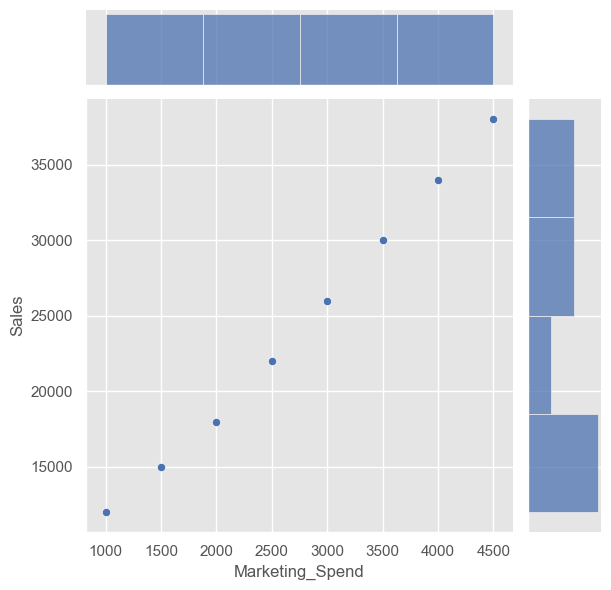

In [47]:
## 10. Joint Plot - sns.jointplot()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Dataset
sales_df = pd.DataFrame({
    "Marketing_Spend": [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500],
    "Sales": [12000, 15000, 18000, 22000, 26000, 30000, 34000, 38000]
})

sns.jointplot(
    data=sales_df,
    x="Marketing_Spend",
    y="Sales",
    kind="scatter",
    height=6
)

plt.show()

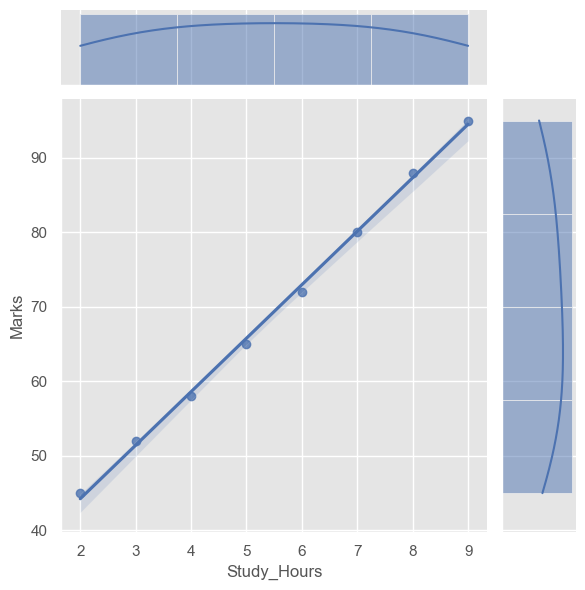

In [48]:
## Intermediate Example: Study Hours vs Marks

student_df = pd.DataFrame({
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "Marks": [45, 52, 58, 65, 72, 80, 88, 95]
})

sns.jointplot(
    data=student_df,
    x="Study_Hours",
    y="Marks",
    kind="reg",
    height=6
)

plt.show()

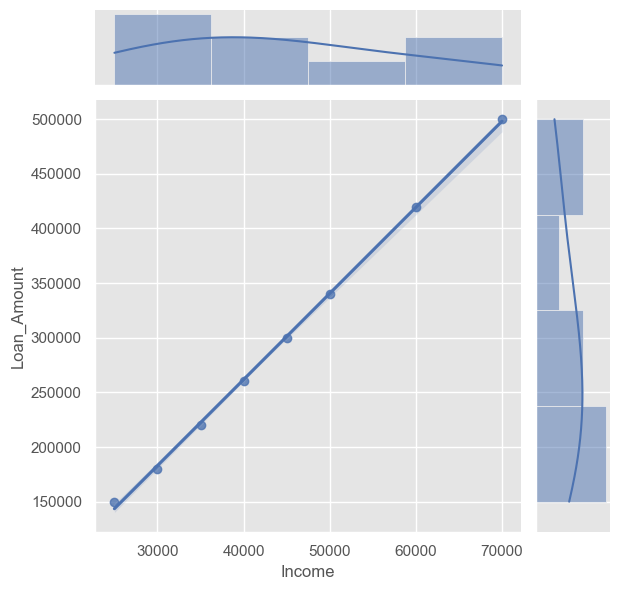

In [49]:
## Real Industry Example: Banking - Customer Income vs Loan Amount

bank_df = pd.DataFrame({
    "Income": [25000, 30000, 35000, 40000, 45000, 50000, 60000, 70000],
    "Loan_Amount": [150000, 180000, 220000, 260000, 300000, 340000, 420000, 500000]
})

sns.jointplot(
    data=bank_df,
    x="Income",
    y="Loan_Amount",
    kind="reg",
    height=6
)

plt.show()

## 11.Violin Plot -- sns.violinplot()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\3310606044.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


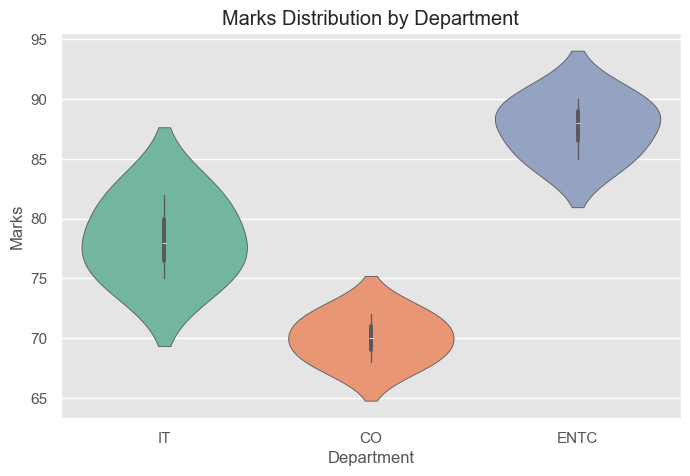

In [50]:
## 11. Violin Plot - sns.violinplot()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Dataset
student_df = pd.DataFrame({
    "Department": ["IT","IT","IT","CO","CO","CO","ENTC","ENTC","ENTC"],
    "Marks": [78, 82, 75, 68, 72, 70, 85, 88, 90]
})

plt.figure(figsize=(8,5))

sns.violinplot(
    data=student_df,
    x="Department",
    y="Marks",
    palette="Set2"
)

plt.title("Marks Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Marks")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\48707115.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


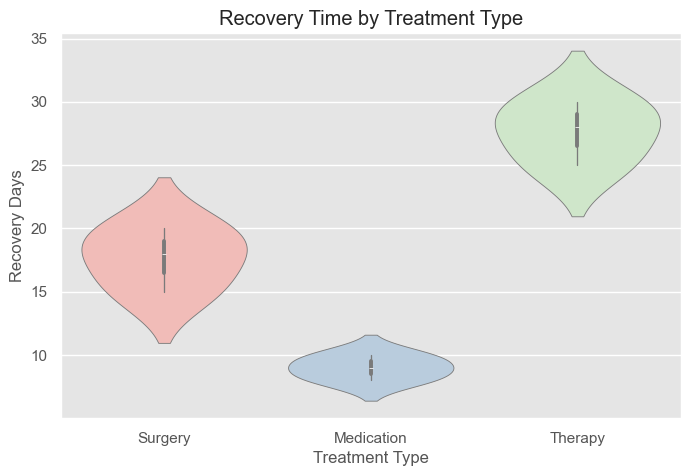

In [51]:
## Intermediate Example: Patient Recovery Time

hospital_df = pd.DataFrame({
    "Treatment": ["Surgery","Surgery","Surgery",
                  "Medication","Medication","Medication",
                  "Therapy","Therapy","Therapy"],
    "Recovery_Days": [15, 18, 20, 8, 10, 9, 25, 28, 30]
})

plt.figure(figsize=(8,5))

sns.violinplot(
    data=hospital_df,
    x="Treatment",
    y="Recovery_Days",
    palette="Pastel1"
)

plt.title("Recovery Time by Treatment Type")
plt.xlabel("Treatment Type")
plt.ylabel("Recovery Days")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8396\1175252580.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


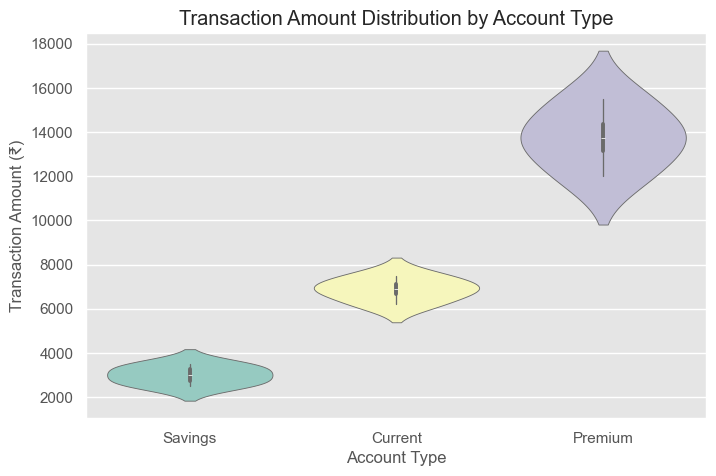

In [52]:
## Real Industry Example: Banking - Transaction Amount Distribution

bank_df = pd.DataFrame({
    "Account_Type": ["Savings","Savings","Savings","Savings",
                     "Current","Current","Current","Current",
                     "Premium","Premium","Premium","Premium"],
    "Transaction_Amount": [2500, 3200, 2800, 3500,
                           6200, 7000, 6800, 7500,
                           12000, 13500, 14000, 15500]
})

plt.figure(figsize=(8,5))

sns.violinplot(
    data=bank_df,
    x="Account_Type",
    y="Transaction_Amount",
    palette="Set3"
)

plt.title("Transaction Amount Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Transaction Amount (₹)")

plt.show()

## 12. Pair Plot -- sns.pairplot()

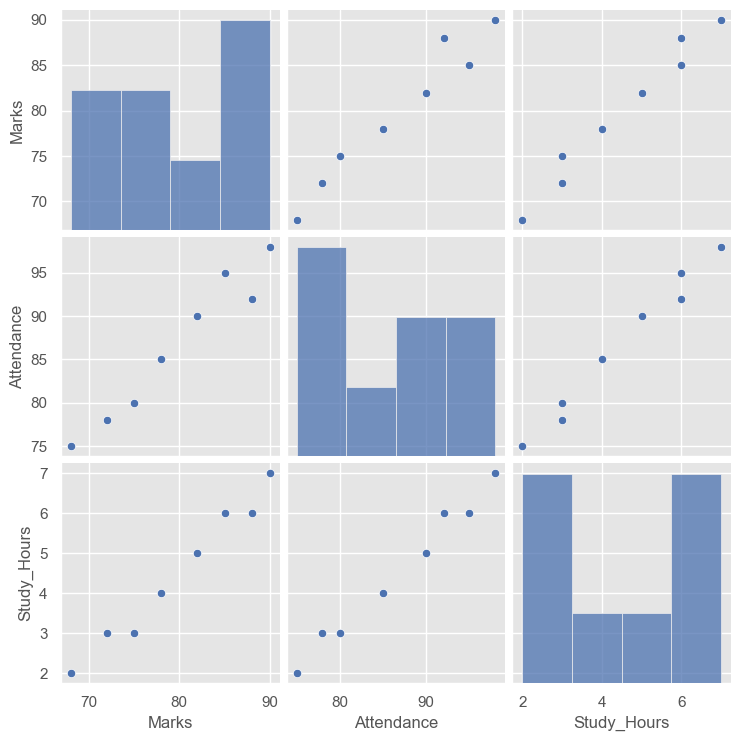

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Dataset
student_df = pd.DataFrame({
    "Marks": [78, 82, 75, 68, 72, 85, 90, 88],
    "Attendance": [85, 90, 80, 75, 78, 95, 98, 92],
    "Study_Hours": [4, 5, 3, 2, 3, 6, 7, 6]
})

sns.pairplot(student_df)

plt.show()

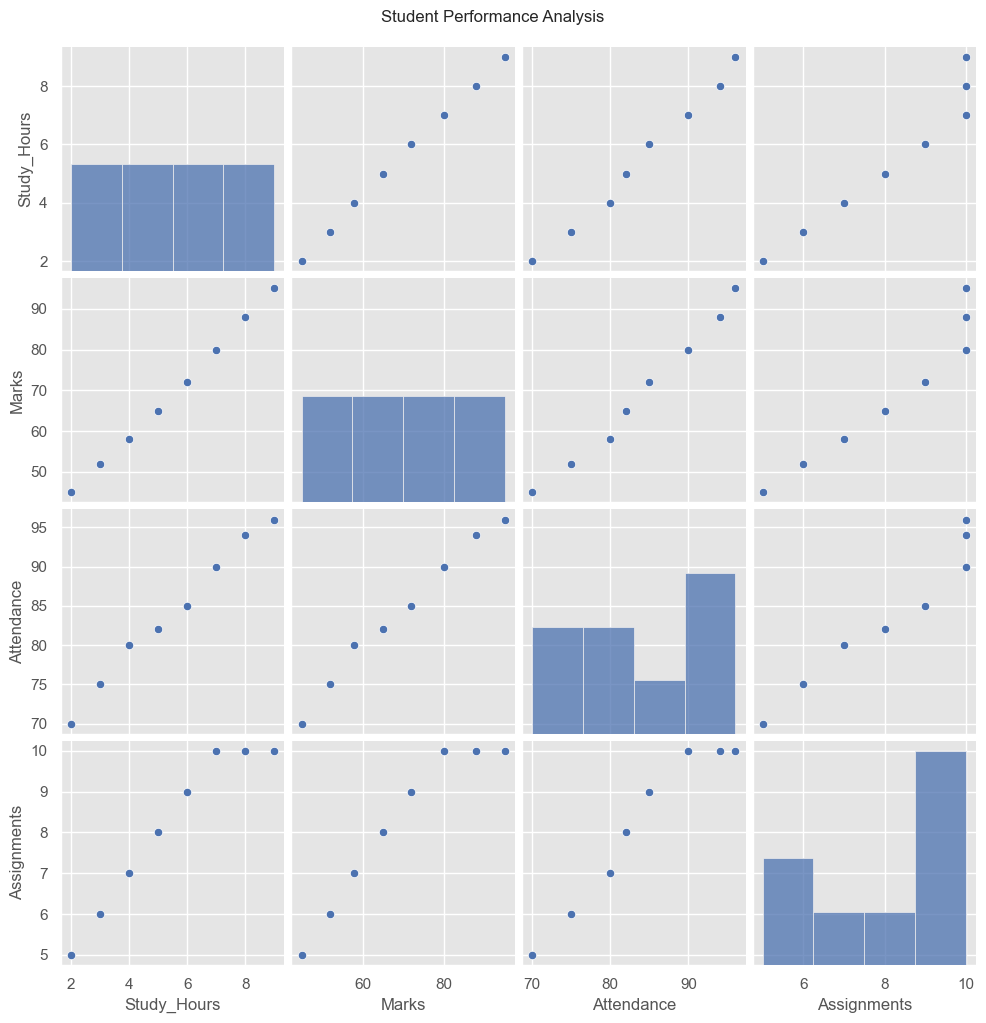

In [54]:
## Intermediate Example: Student Performance Analysis

student_df = pd.DataFrame({
    "Study_Hours": [2,3,4,5,6,7,8,9],
    "Marks": [45,52,58,65,72,80,88,95],
    "Attendance": [70,75,80,82,85,90,94,96],
    "Assignments": [5,6,7,8,9,10,10,10]
})

sns.pairplot(student_df)

plt.suptitle("Student Performance Analysis", y=1.02)

plt.show()

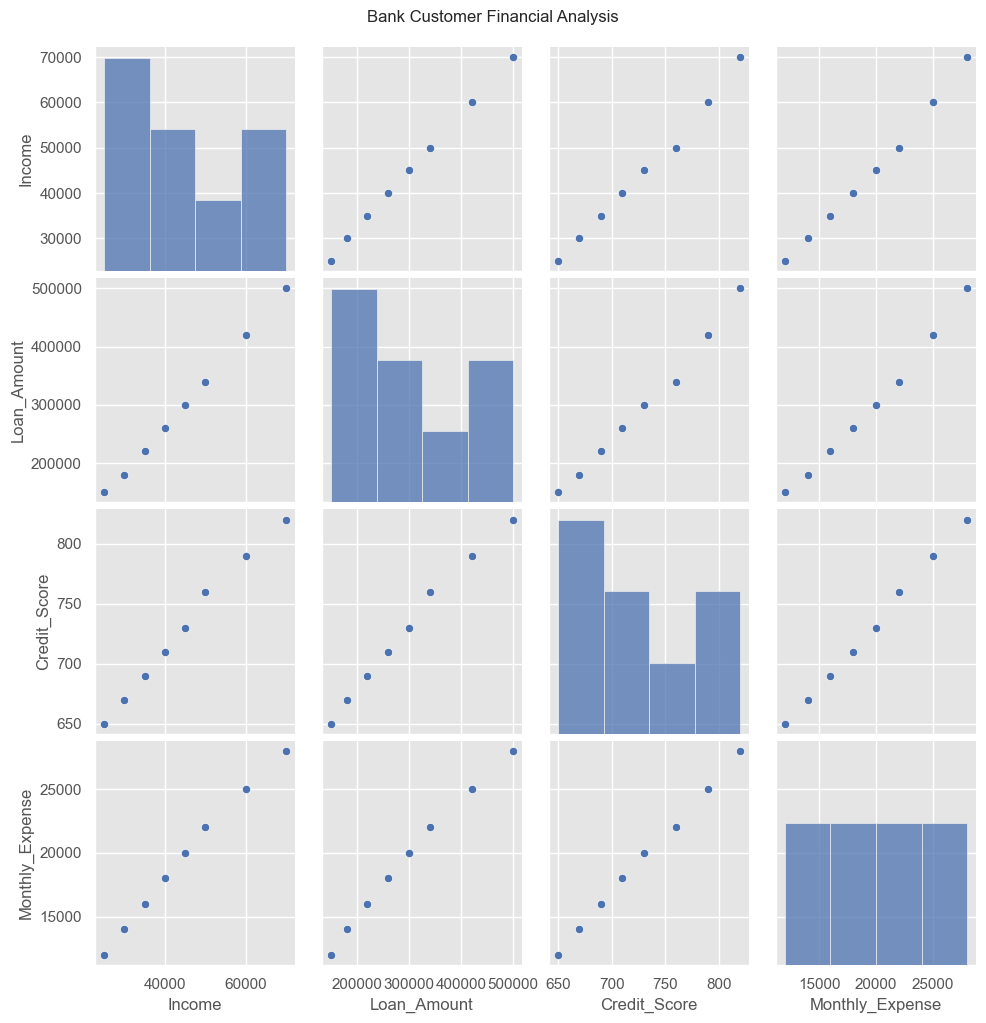

In [55]:
## Real Industry Example: Banking Customer Analysis

bank_df = pd.DataFrame({
    "Income": [25000,30000,35000,40000,45000,50000,60000,70000],
    "Loan_Amount": [150000,180000,220000,260000,300000,340000,420000,500000],
    "Credit_Score": [650,670,690,710,730,760,790,820],
    "Monthly_Expense": [12000,14000,16000,18000,20000,22000,25000,28000]
})

sns.pairplot(bank_df)

plt.suptitle("Bank Customer Financial Analysis", y=1.02)

plt.show()

## 13. Heatmap -- sns.heatmap()

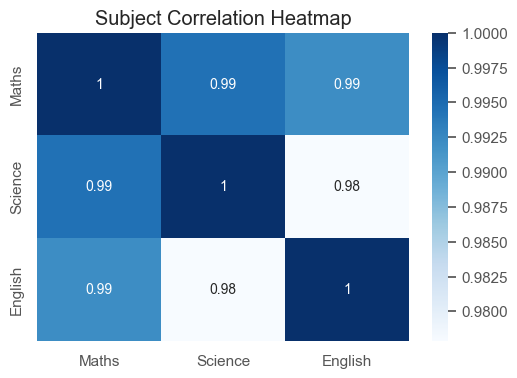

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Dataset
student_df = pd.DataFrame({
    "Maths": [80, 75, 90, 85, 70],
    "Science": [78, 72, 88, 84, 69],
    "English": [85, 80, 92, 87, 75]
})

plt.figure(figsize=(6,4))

sns.heatmap(
    student_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Subject Correlation Heatmap")
plt.show()

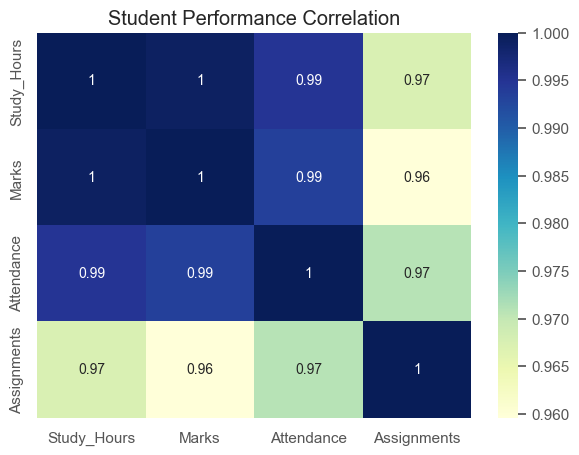

In [57]:
## Intermediate Example: Student Performance Analysis

student_df = pd.DataFrame({
    "Study_Hours": [2,3,4,5,6,7,8,9],
    "Marks": [45,52,58,65,72,80,88,95],
    "Attendance": [70,75,80,82,85,90,94,96],
    "Assignments": [5,6,7,8,9,10,10,10]
})

plt.figure(figsize=(7,5))

sns.heatmap(
    student_df.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Student Performance Correlation")
plt.show()

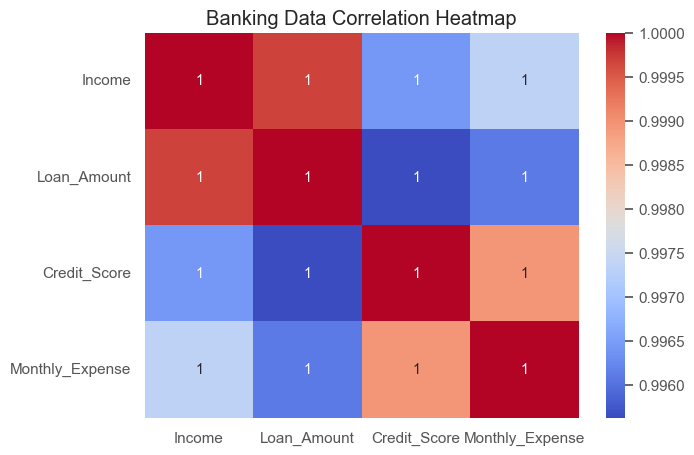

In [58]:
## Real Industry Example: Banking Customer Analysis

bank_df = pd.DataFrame({
    "Income": [25000,30000,35000,40000,45000,50000,60000,70000],
    "Loan_Amount": [150000,180000,220000,260000,300000,340000,420000,500000],
    "Credit_Score": [650,670,690,710,730,760,790,820],
    "Monthly_Expense": [12000,14000,16000,18000,20000,22000,25000,28000]
})

plt.figure(figsize=(7,5))

sns.heatmap(
    bank_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Banking Data Correlation Heatmap")
plt.show()